Sample Dataset:
     Quantity  UnitPrice  Discount  TotalPrice
0         14        160      0.00      2240.0
1          1        540      0.00       540.0
2         14        350      0.10      4410.0
3         18        380      0.15      5814.0
4         18        240      0.00      4320.0
5          2        385      0.15       654.5
6          7         18      0.10       113.4
7          3        330      0.15       841.5
8          3        430      0.05      1225.5
9          5        320      0.10      1440.0
10        15        525      0.10      7087.5
11        19        210      0.00      3990.0

Mean Squared Error: 703288.1669187668
R2 Score: 0.6199610703905127


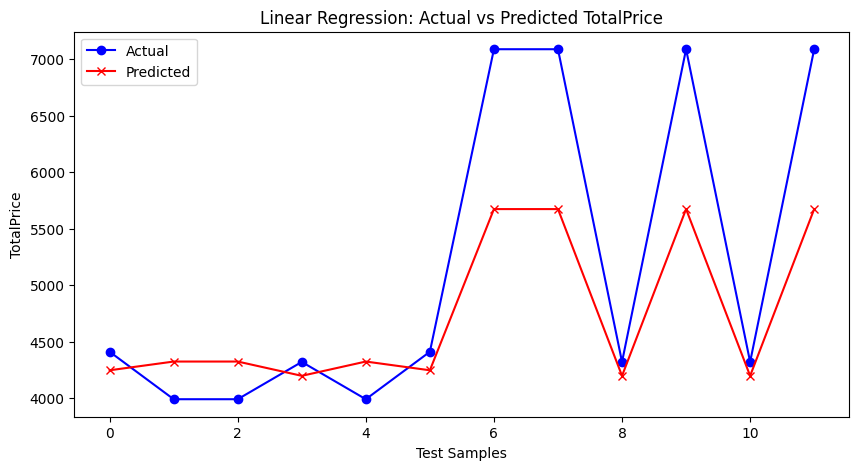

In [ ]:
#============================
# Linear Regression using Python
#============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#============================
# 1. Create Universal Dataset (60 rows)
#============================
data = {
    'Quantity': [14,1,14,18,18,2,7,3,3,5,15,19]*5,  
    'UnitPrice': [160,540,350,380,240,385,18,330,430,320,525,210]*5,
    'Discount': [0,0,0.1,0.15,0,0.15,0.1,0.15,0.05,0.1,0.1,0]*5
}

df = pd.DataFrame(data)

# Calculate TotalPrice as target
df['TotalPrice'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

print("Sample Dataset:\n", df.head(12))

#============================
# 2. Select Features and Target
#============================
X = df[['Quantity','UnitPrice','Discount']]
y = df['TotalPrice']

#============================
# 3. Split Dataset
#============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

#============================
# 4. Scale Features
#============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#============================
# 5. Train Linear Regression Model
#============================
model = LinearRegression()
model.fit(X_train_scaled, y_train)

#============================
# 6. Make Predictions
#============================
y_pred = model.predict(X_test_scaled)

#============================
# 7. Evaluate Model
#============================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

#============================
# 8. Plot Predicted vs Actual Values
#============================
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', marker='o', color='blue')
plt.plot(y_pred, label='Predicted', marker='x', color='red')
plt.title("Linear Regression: Actual vs Predicted TotalPrice")
plt.xlabel("Test Samples")
plt.ylabel("TotalPrice")
plt.legend()
plt.show()

#============================
# Final Answer
#============================
# Linear Regression predicts TotalPrice based on Quantity, UnitPrice, and Discount
# Mean Squared Error and R2 Score are displayed
# Line plot shows predicted vs actual values clearly